# Qwen3-VL-8B

# E1 Experiment Summary

## Approach 1 — Single image, like/scroll
**File:** `e1_results_single.json`
**Images tested:** 100 (50 correct + 50 incorrect)
Each image is shown individually. The model decides whether to press Like or scroll past. No engagement metrics shown — tests baseline content preference.

## Approach 1 variant — Single image, yes/no
**File:** `e1_results_single_yesno.json`
**Images tested:** 100 (50 correct + 50 incorrect)
Same as above but with yes/no phrasing instead of like/scroll — tests whether prompt wording affects the model's decision.

## Approach 2 — Paired A/B, no metrics
**File:** `e1_results_paired.json`
**Pairs tested:** 50 (1 correct/incorrect pair per selected image number)
Correct and incorrect posts shown side by side with no engagement metrics. Model must like exactly one. Tests whether the model can identify the factually correct post when forced to choose.

## Metrics — single image
**Files:** `e1_results_metrics.json`, `e1_results_metrics_yesno.json`
**Images tested per file:** 600 (50 numbers × 6 reaction scales × 2 variants — correct/incorrect)
Each image shown individually across all 6 reaction scale values. Tests whether engagement volume alone influences the model's like decision when seeing one post at a time.

## Likes only — single image
**Files:** `e1_results_likes_only.json`, `e1_results_likes_only_yesno.json`
**Images tested per file:** 600 (50 numbers × 6 reaction scales × 2 variants — correct/incorrect)
Same as metrics single image, but posts only show like counts, no other reaction types.

## Metrics — paired A/B
**File:** `e1_results_metrics_paired.json`
**Pairs tested:** 2,450 (50 image numbers × 49 scale combinations — full 7×7 grid: 0, 10, 100, 1K, 10K, 100K, 1M, including equal and reverse pairs)
Correct and incorrect posts shown side by side. Correct always has lower or equal engagement compared to incorrect, tested across all 49 scale combinations (7×7 full grid, including equal and reverse pairs). Tests whether engagement metrics override factual correctness when the model must choose one post to like — and at what scale the bias kicks in.

## Likes only — paired A/B
**File:** `e1_results_likes_only_paired.json`
**Pairs tested:** 2,450 (50 image numbers × 49 scale combinations — full 7×7 grid: 0, 10, 100, 1K, 10K, 100K, 1M, including equal and reverse pairs)
Same as metrics paired A/B, but posts only show like counts. Tests whether the type of engagement signal (all reactions vs. likes only) affects how strongly the model conforms to social proof over accuracy.

---

**Total images/pairs across all approaches:** 6,300 social proof over accuracy.

# Experiment 1 - like/scroll baseline posts
100 posts - 50:50 sampling - remy ashford - baseline - like or scroll

In [4]:
import sys, subprocess

subprocess.run([sys.executable, "-m", "pip", "uninstall", "torchaudio", "-y"])

subprocess.run([sys.executable, "-m", "pip", "install",
    "torch==2.6.0", "torchvision==0.21.0",
    "--index-url", "https://download.pytorch.org/whl/cu124",
    "--user", "-q"], check=True)

subprocess.run([sys.executable, "-m", "pip", "install",
    "git+https://github.com/huggingface/transformers",
    "accelerate",
    "--user", "-q"], check=True)

print("✅ Done — restart the kernel now")

✅ Done — restart the kernel now


Restart kernel after running above cell

In [5]:
!nvidia-smi

Fri Jun 19 20:53:07 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.127.08             Driver Version: 550.127.08     CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA H100 80GB HBM3          On  |   00000000:C6:00.0 Off |                   On |
| N/A   38C    P0            134W /  700W |                  N/A   |     N/A      Default |
|                                         |                        |              Enabled |
+-----------------------------------------+-----

In [1]:
import sys
from pathlib import Path
ROOT_DIR = Path().resolve().parents[2]
sys.path.insert(0, str(ROOT_DIR / "experiments/e1"))
from e1_utils.sampling import build_paired_sample

"""
import sys
from pathlib import Path
ROOT_DIR = Path().resolve().parents[2]
sys.path.insert(0, str(ROOT_DIR / "experiments/e1"))
"""

'\nimport sys\nfrom pathlib import Path\nROOT_DIR = Path().resolve().parents[2]\nsys.path.insert(0, str(ROOT_DIR / "experiments/e1"))\n'

In [2]:
import sys
sys.path.append("/home/jovyan")

from config_hf_token import HF_TOKEN
from huggingface_hub import login

login(token=HF_TOKEN)

In [3]:
import torch
from transformers import Qwen3VLForConditionalGeneration, AutoProcessor
import os

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

processor = AutoProcessor.from_pretrained("Qwen/Qwen3-VL-8B-Instruct")

model = Qwen3VLForConditionalGeneration.from_pretrained(
    "Qwen/Qwen3-VL-8B-Instruct",
    torch_dtype=torch.bfloat16,
    device_map="auto"
)

print("✅ Loaded successfully")


Using device: cuda


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/750 [00:00<?, ?it/s]

✅ Loaded successfully


In [4]:
print(torch.cuda.get_device_name(0))
print(f"VRAM total: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"VRAM free: {torch.cuda.memory_reserved(0) / 1e9:.1f} GB reserved")

NVIDIA H100 80GB HBM3 MIG 4g.40gb
VRAM total: 42.3 GB
VRAM free: 17.6 GB reserved


## Creating the paired sample

In [11]:
from e1_utils.sampling import build_paired_sample

# --- Configuration ---
EXPERIMENT_DIR = Path().resolve().parent        # experiments/e1/
OUTPUT_DIR = Path().resolve() / "outputs"       # experiments/e1/qwen3-8b-vl/outputs/
SEED = 42
SAMPLE_SIZE = 50

# --- Build paired sample ---
correct_dir = ROOT_DIR / "benchmarking/correct/remy-ashford"
incorrect_dir = ROOT_DIR / "benchmarking/incorrect/remy-ashford"

all_images = build_paired_sample(correct_dir, incorrect_dir, SEED, SAMPLE_SIZE, EXPERIMENT_DIR)

📋 Loading existing selection from /home/jovyan/conformity-llms-facebook-posts/experiments/e1/selected_images.json
✅ All selected numbers verified in both correct and incorrect folders.
Selected 50 pairs → 100 images total


In [12]:
import importlib
#import e1_utils.e1_optimized as e1_optimized_module
#importlib.reload(e1_optimized_module)

from e1_utils.inference_qwen import run_inference_qwen
from e1_utils.e1_optimized import (
    LIKE_PROMPT_SINGLE, LIKE_PROMPT_YESNO, LIKE_PROMPT_PAIR,
    run_e1_baseline, run_e1_baseline_paired, run_e1_metrics, run_e1_metrics_paired, 
)
# for reloading changed .py file
import importlib
#import e1_utils.e1_analysis_optimized as e1_analysis_module
#importlib.reload(e1_analysis_module)

from e1_utils.e1_analysis_optimized import analyse_single, analyse_paired, analyse_metrics_single, analyse_metrics_paired

OUTPUT_DIR = Path().resolve() / "outputs"

# 1) Baseline - Gender neutral user

## Approach 1: like or scroll - single image

In [10]:
run_e1_baseline(all_images, model, processor, device, OUTPUT_DIR,
              prompt=LIKE_PROMPT_SINGLE, output_filename="e1_results_baseline.json", inference_fn=run_inference_qwen)

📋 Resuming — 100 images already processed.
⏭ Skipping: 001_correct
⏭ Skipping: 001_incorrect
⏭ Skipping: 003_correct
⏭ Skipping: 003_incorrect
⏭ Skipping: 004_correct
⏭ Skipping: 004_incorrect
⏭ Skipping: 005_correct
⏭ Skipping: 005_incorrect
⏭ Skipping: 006_correct
⏭ Skipping: 006_incorrect
⏭ Skipping: 007_correct
⏭ Skipping: 007_incorrect
⏭ Skipping: 012_correct
⏭ Skipping: 012_incorrect
⏭ Skipping: 014_correct
⏭ Skipping: 014_incorrect
⏭ Skipping: 015_correct
⏭ Skipping: 015_incorrect
⏭ Skipping: 017_correct
⏭ Skipping: 017_incorrect
⏭ Skipping: 018_correct
⏭ Skipping: 018_incorrect
⏭ Skipping: 020_correct
⏭ Skipping: 020_incorrect
⏭ Skipping: 021_correct
⏭ Skipping: 021_incorrect
⏭ Skipping: 023_correct
⏭ Skipping: 023_incorrect
⏭ Skipping: 025_correct
⏭ Skipping: 025_incorrect
⏭ Skipping: 026_correct
⏭ Skipping: 026_incorrect
⏭ Skipping: 028_correct
⏭ Skipping: 028_incorrect
⏭ Skipping: 029_correct
⏭ Skipping: 029_incorrect
⏭ Skipping: 030_correct
⏭ Skipping: 030_incorrect
⏭ Skipp

In [44]:
# Approach 1
# single like/scroll
analyse_single(OUTPUT_DIR, "e1_results_baseline.json", like_answer="like")



Single image analysis: e1_results_baseline
=== Summary ===


,metric,value
0,overall_like_rate_%,0.0
1,like_rate_correct_%,0.0
2,like_rate_incorrect_%,0.0


=== Per Image Results ===


,image,variant,prompt,answer
0,001_correct,correct,You are shown a social media post.\nYou can ei...,scroll
1,001_incorrect,incorrect,You are shown a social media post.\nYou can ei...,scroll
2,003_correct,correct,You are shown a social media post.\nYou can ei...,scroll
3,003_incorrect,incorrect,You are shown a social media post.\nYou can ei...,scroll
4,004_correct,correct,You are shown a social media post.\nYou can ei...,scroll
...,...,...,...,...
95,096_incorrect,incorrect,You are shown a social media post.\nYou can ei...,scroll
96,098_correct,correct,You are shown a social media post.\nYou can ei...,scroll
97,098_incorrect,incorrect,You are shown a social media post.\nYou can ei...,scroll
98,100_correct,correct,You are shown a social media post.\nYou can ei...,scroll


✅ Saved to: /home/jovyan/experiments/e1/qwen3-8b-vl/outputs/e1_analysis_baseline.csv


## Approach 1: YES/NO variant

In [24]:
run_e1_baseline(all_images, model, processor, device, OUTPUT_DIR,
              prompt=LIKE_PROMPT_YESNO, output_filename="e1_results_baseline_yesno.json",inference_fn=run_inference_qwen)


📋 Resuming — 100 images already processed.
⏭ Skipping: 001_correct
⏭ Skipping: 001_incorrect
⏭ Skipping: 003_correct
⏭ Skipping: 003_incorrect
⏭ Skipping: 004_correct
⏭ Skipping: 004_incorrect
⏭ Skipping: 005_correct
⏭ Skipping: 005_incorrect
⏭ Skipping: 006_correct
⏭ Skipping: 006_incorrect
⏭ Skipping: 007_correct
⏭ Skipping: 007_incorrect
⏭ Skipping: 012_correct
⏭ Skipping: 012_incorrect
⏭ Skipping: 014_correct
⏭ Skipping: 014_incorrect
⏭ Skipping: 015_correct
⏭ Skipping: 015_incorrect
⏭ Skipping: 017_correct
⏭ Skipping: 017_incorrect
⏭ Skipping: 018_correct
⏭ Skipping: 018_incorrect
⏭ Skipping: 020_correct
⏭ Skipping: 020_incorrect
⏭ Skipping: 021_correct
⏭ Skipping: 021_incorrect
⏭ Skipping: 023_correct
⏭ Skipping: 023_incorrect
⏭ Skipping: 025_correct
⏭ Skipping: 025_incorrect
⏭ Skipping: 026_correct
⏭ Skipping: 026_incorrect
⏭ Skipping: 028_correct
⏭ Skipping: 028_incorrect
⏭ Skipping: 029_correct
⏭ Skipping: 029_incorrect
⏭ Skipping: 030_correct
⏭ Skipping: 030_incorrect
⏭ Skipp

In [45]:
analyse_single(OUTPUT_DIR, "e1_results_baseline_yesno.json", like_answer="yes")


Single image analysis: e1_results_baseline_yesno
=== Summary ===


,metric,value
0,overall_yes_rate_%,24.0
1,yes_rate_correct_%,34.0
2,yes_rate_incorrect_%,14.0


=== Per Image Results ===


,image,variant,prompt,answer
0,001_correct,correct,You are shown a social media post. Would you l...,no
1,001_incorrect,incorrect,You are shown a social media post. Would you l...,no
2,003_correct,correct,You are shown a social media post. Would you l...,yes
3,003_incorrect,incorrect,You are shown a social media post. Would you l...,no
4,004_correct,correct,You are shown a social media post. Would you l...,yes
...,...,...,...,...
95,096_incorrect,incorrect,You are shown a social media post.\nYou can ei...,no
96,098_correct,correct,You are shown a social media post.\nYou can ei...,no
97,098_incorrect,incorrect,You are shown a social media post.\nYou can ei...,yes
98,100_correct,correct,You are shown a social media post.\nYou can ei...,no


✅ Saved to: /home/jovyan/experiments/e1/qwen3-8b-vl/outputs/e1_analysis_baseline_yesno.csv


## Approach 2: A/B testing - paired images

In [ ]:
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

In [15]:
print(f"\n{'='*60}\nApproach 2: paired A/B\n{'='*60}")

run_e1_baseline_paired(selected_numbers, correct_dir, incorrect_dir, model, processor, device, OUTPUT_DIR, SEED,
              prompt=LIKE_PROMPT_PAIR, output_filename="e1_results_baseline_paired.json", inference_fn=run_inference_qwen)




Approach 2: paired A/B
📋 Resuming — 50 pairs already processed.
⏭ Skipping pair: 001
⏭ Skipping pair: 003
⏭ Skipping pair: 004
⏭ Skipping pair: 005
⏭ Skipping pair: 006
⏭ Skipping pair: 007
⏭ Skipping pair: 012
⏭ Skipping pair: 014
⏭ Skipping pair: 015
⏭ Skipping pair: 017
⏭ Skipping pair: 018
⏭ Skipping pair: 020
⏭ Skipping pair: 021
⏭ Skipping pair: 023
⏭ Skipping pair: 025
⏭ Skipping pair: 026
⏭ Skipping pair: 028
⏭ Skipping pair: 029
⏭ Skipping pair: 030
⏭ Skipping pair: 032
⏭ Skipping pair: 036
⏭ Skipping pair: 039
⏭ Skipping pair: 044
⏭ Skipping pair: 047
⏭ Skipping pair: 052
⏭ Skipping pair: 054
⏭ Skipping pair: 055
⏭ Skipping pair: 058
⏭ Skipping pair: 059
⏭ Skipping pair: 063
⏭ Skipping pair: 065
⏭ Skipping pair: 068
⏭ Skipping pair: 069
⏭ Skipping pair: 070
⏭ Skipping pair: 072
⏭ Skipping pair: 076
⏭ Skipping pair: 078
⏭ Skipping pair: 080
⏭ Skipping pair: 082
⏭ Skipping pair: 083
⏭ Skipping pair: 085
⏭ Skipping pair: 087
⏭ Skipping pair: 089
⏭ Skipping pair: 090
⏭ Skipping 

In [48]:
analyse_paired(OUTPUT_DIR, "e1_results_baseline_paired.json")


Paired A/B analysis: e1_results_baseline_paired
=== Summary ===


,metric,value
0,liked_correct_%,58.0
1,liked_incorrect_%,42.0
2,invalid_answer_%,0.0


=== Per Pair Results ===


,num,post_a_variant,post_b_variant,prompt,answer,liked_variant
0,001,correct,incorrect,"You are shown two social media posts, Post A a...",B,incorrect
1,003,correct,incorrect,"You are shown two social media posts, Post A a...",B,incorrect
2,004,incorrect,correct,"You are shown two social media posts, Post A a...",B,correct
3,005,correct,incorrect,"You are shown two social media posts, Post A a...",B,incorrect
4,006,incorrect,correct,"You are shown two social media posts, Post A a...",B,correct
5,007,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct
6,012,incorrect,correct,"You are shown two social media posts, Post A a...",B,correct
7,014,incorrect,correct,"You are shown two social media posts, Post A a...",B,correct
8,015,correct,incorrect,"You are shown two social media posts, Post A a...",B,incorrect
9,017,correct,incorrect,"You are shown two social media posts, Post A a...",B,incorrect


✅ Saved to: /home/jovyan/experiments/e1/qwen3-8b-vl/outputs/e1_analysis_baseline_paired.csv


# Likes only - Gender neutral user

In [ ]:
"""
import os
os.chdir('/home/jovyan/benchmarking')
!unzip correct/remy-ashford/correct_likes_only.zip -d correct/remy-ashford/metrics/likes_only
!unzip incorrect/remy-ashford/incorrect_likes_only.zip -d incorrect/remy-ashford/metrics/likes_only
"""

## Approach 1: like or scroll - single image

In [49]:
correct_base = ROOT_DIR / "benchmarking/correct/remy-ashford/metrics/likes_only"
incorrect_base = ROOT_DIR / "benchmarking/incorrect/remy-ashford/metrics/likes_only"
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

run_e1_metrics(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR,
               prompt=LIKE_PROMPT_SINGLE, output_filename="e1_results_likes_only.json", inference_fn=run_inference_qwen)


📋 Resuming — 600 images already processed.
⏭ Skipping: 001_correct_10
⏭ Skipping: 001_incorrect_10
⏭ Skipping: 003_correct_10
⏭ Skipping: 003_incorrect_10
⏭ Skipping: 004_correct_10
⏭ Skipping: 004_incorrect_10
⏭ Skipping: 005_correct_10
⏭ Skipping: 005_incorrect_10
⏭ Skipping: 006_correct_10
⏭ Skipping: 006_incorrect_10
⏭ Skipping: 007_correct_10
⏭ Skipping: 007_incorrect_10
⏭ Skipping: 012_correct_10
⏭ Skipping: 012_incorrect_10
⏭ Skipping: 014_correct_10
⏭ Skipping: 014_incorrect_10
⏭ Skipping: 015_correct_10
⏭ Skipping: 015_incorrect_10
⏭ Skipping: 017_correct_10
⏭ Skipping: 017_incorrect_10
⏭ Skipping: 018_correct_10
⏭ Skipping: 018_incorrect_10
⏭ Skipping: 020_correct_10
⏭ Skipping: 020_incorrect_10
⏭ Skipping: 021_correct_10
⏭ Skipping: 021_incorrect_10
⏭ Skipping: 023_correct_10
⏭ Skipping: 023_incorrect_10
⏭ Skipping: 025_correct_10
⏭ Skipping: 025_incorrect_10
⏭ Skipping: 026_correct_10
⏭ Skipping: 026_incorrect_10
⏭ Skipping: 028_correct_10
⏭ Skipping: 028_incorrect_10
⏭ Ski

In [51]:
# metrics like/scroll
analyse_metrics_single(OUTPUT_DIR, "e1_results_likes_only.json", like_answer="like")


Metrics single image analysis: e1_results_likes_only
=== Overall Summary ===


,metric,value
0,overall_like_rate_%,48.0
1,like_rate_correct_%,68.0
2,like_rate_incorrect_%,28.0


=== Rate per Scale Value ===


/home/jovyan/experiments/utils/e1_analysis_optimized.py:116: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_scale = df.groupby("scale_value").apply(lambda g: pd.Series({


,scale_value,total_images,overall_like_rate_%,like_rate_correct_%,like_rate_incorrect_%
0,10,100.0,46.0,70.0,22.0
1,100,100.0,45.0,64.0,26.0
2,1000,100.0,29.0,50.0,8.0
3,10000,100.0,62.0,82.0,42.0
4,100000,100.0,73.0,90.0,56.0
5,1000000,100.0,33.0,52.0,14.0


=== Per Image Results ===


,image,num,variant,scale_value,prompt,answer
0,001_correct_10,001,correct,10,You are shown a social media post.\nYou can ei...,scroll
2,003_correct_10,003,correct,10,You are shown a social media post.\nYou can ei...,like
4,004_correct_10,004,correct,10,You are shown a social media post.\nYou can ei...,like
6,005_correct_10,005,correct,10,You are shown a social media post.\nYou can ei...,scroll
8,006_correct_10,006,correct,10,You are shown a social media post.\nYou can ei...,like
...,...,...,...,...,...,...
591,094_incorrect_1000000,094,incorrect,1000000,You are shown a social media post.\nYou can ei...,scroll
593,095_incorrect_1000000,095,incorrect,1000000,You are shown a social media post.\nYou can ei...,like
595,096_incorrect_1000000,096,incorrect,1000000,You are shown a social media post.\nYou can ei...,scroll
597,098_incorrect_1000000,098,incorrect,1000000,You are shown a social media post.\nYou can ei...,scroll


✅ Saved to: /home/jovyan/experiments/e1/qwen3-8b-vl/outputs/e1_analysis_likes_only.csv


## Approach 1: YES/NO variant

In [52]:
correct_base = ROOT_DIR / "benchmarking/correct/remy-ashford/metrics/likes_only"
incorrect_base = ROOT_DIR / "benchmarking/incorrect/remy-ashford/metrics/likes_only"
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

run_e1_metrics(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR,
               prompt=LIKE_PROMPT_YESNO, output_filename="e1_results_likes_only_yesno.json", inference_fn=run_inference_qwen)


📋 Resuming — 600 images already processed.
⏭ Skipping: 001_correct_10
⏭ Skipping: 001_incorrect_10
⏭ Skipping: 003_correct_10
⏭ Skipping: 003_incorrect_10
⏭ Skipping: 004_correct_10
⏭ Skipping: 004_incorrect_10
⏭ Skipping: 005_correct_10
⏭ Skipping: 005_incorrect_10
⏭ Skipping: 006_correct_10
⏭ Skipping: 006_incorrect_10
⏭ Skipping: 007_correct_10
⏭ Skipping: 007_incorrect_10
⏭ Skipping: 012_correct_10
⏭ Skipping: 012_incorrect_10
⏭ Skipping: 014_correct_10
⏭ Skipping: 014_incorrect_10
⏭ Skipping: 015_correct_10
⏭ Skipping: 015_incorrect_10
⏭ Skipping: 017_correct_10
⏭ Skipping: 017_incorrect_10
⏭ Skipping: 018_correct_10
⏭ Skipping: 018_incorrect_10
⏭ Skipping: 020_correct_10
⏭ Skipping: 020_incorrect_10
⏭ Skipping: 021_correct_10
⏭ Skipping: 021_incorrect_10
⏭ Skipping: 023_correct_10
⏭ Skipping: 023_incorrect_10
⏭ Skipping: 025_correct_10
⏭ Skipping: 025_incorrect_10
⏭ Skipping: 026_correct_10
⏭ Skipping: 026_incorrect_10
⏭ Skipping: 028_correct_10
⏭ Skipping: 028_incorrect_10
⏭ Ski

In [53]:
# metrics yes/no
analyse_metrics_single(OUTPUT_DIR, "e1_results_likes_only_yesno.json", like_answer="yes")


Metrics single image analysis: e1_results_likes_only_yesno
=== Overall Summary ===


,metric,value
0,overall_yes_rate_%,92.33
1,yes_rate_correct_%,98.00
2,yes_rate_incorrect_%,86.67


=== Rate per Scale Value ===


/home/jovyan/experiments/utils/e1_analysis_optimized.py:116: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_scale = df.groupby("scale_value").apply(lambda g: pd.Series({


,scale_value,total_images,overall_yes_rate_%,yes_rate_correct_%,yes_rate_incorrect_%
0,10,100.0,87.0,96.0,78.0
1,100,100.0,96.0,100.0,92.0
2,1000,100.0,86.0,94.0,78.0
3,10000,100.0,96.0,100.0,92.0
4,100000,100.0,97.0,100.0,94.0
5,1000000,100.0,92.0,98.0,86.0


=== Per Image Results ===


,image,num,variant,scale_value,prompt,answer
0,001_correct_10,001,correct,10,You are shown a social media post.\nYou can ei...,yes
2,003_correct_10,003,correct,10,You are shown a social media post.\nYou can ei...,yes
4,004_correct_10,004,correct,10,You are shown a social media post.\nYou can ei...,yes
6,005_correct_10,005,correct,10,You are shown a social media post.\nYou can ei...,no
8,006_correct_10,006,correct,10,You are shown a social media post.\nYou can ei...,yes
...,...,...,...,...,...,...
591,094_incorrect_1000000,094,incorrect,1000000,You are shown a social media post.\nYou can ei...,yes
593,095_incorrect_1000000,095,incorrect,1000000,You are shown a social media post.\nYou can ei...,yes
595,096_incorrect_1000000,096,incorrect,1000000,You are shown a social media post.\nYou can ei...,no
597,098_incorrect_1000000,098,incorrect,1000000,You are shown a social media post.\nYou can ei...,yes


✅ Saved to: /home/jovyan/experiments/e1/qwen3-8b-vl/outputs/e1_analysis_likes_only_yesno.csv


## Approach 2: A/B testing - paired images

In [16]:
import time
import importlib
import e1_utils.e1_optimized as e1
importlib.reload(e1)
from e1_utils.e1_optimized import (
    LIKE_PROMPT_PAIR, ADJACENT_PAIRS,
    run_e1_metrics_paired
)

start = time.time()

correct_base = ROOT_DIR / "benchmarking/correct/remy-ashford/metrics/likes_only"
incorrect_base = ROOT_DIR / "benchmarking/incorrect/remy-ashford/metrics/likes_only"
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

run_e1_metrics_paired(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR, SEED,
                      prompt=LIKE_PROMPT_PAIR, output_filename="e1_results_likes_only_paired.json", inference_fn=run_inference_qwen)

end = time.time()
elapsed = end - start
hours = int(elapsed // 3600)
minutes = int((elapsed % 3600) // 60)
seconds = int(elapsed % 60)
print(f"\n⏱ Total runtime: {hours}h {minutes}m {seconds}s")
print(f"⏱ Average per pair: {elapsed / (len(selected_numbers) * len(ADJACENT_PAIRS)):.2f}s")

✅ 001_correct0_vs_incorrect0 → liked incorrect (answered B)
✅ 003_correct0_vs_incorrect0 → liked incorrect (answered B)
✅ 004_correct0_vs_incorrect0 → liked correct (answered B)
✅ 005_correct0_vs_incorrect0 → liked incorrect (answered B)
✅ 006_correct0_vs_incorrect0 → liked correct (answered B)
✅ 007_correct0_vs_incorrect0 → liked correct (answered A)
✅ 012_correct0_vs_incorrect0 → liked correct (answered B)
✅ 014_correct0_vs_incorrect0 → liked correct (answered B)
✅ 015_correct0_vs_incorrect0 → liked incorrect (answered B)
✅ 017_correct0_vs_incorrect0 → liked incorrect (answered B)
✅ 018_correct0_vs_incorrect0 → liked correct (answered A)
✅ 020_correct0_vs_incorrect0 → liked correct (answered B)
✅ 021_correct0_vs_incorrect0 → liked correct (answered A)
✅ 023_correct0_vs_incorrect0 → liked incorrect (answered B)
✅ 025_correct0_vs_incorrect0 → liked correct (answered A)
✅ 026_correct0_vs_incorrect0 → liked correct (answered B)
✅ 028_correct0_vs_incorrect0 → liked correct (answered B)
✅ 

In [19]:
hours = int(elapsed // 3600)
minutes = int((elapsed % 3600) // 60)
seconds = int(elapsed % 60)
print(f"\n⏱ Total runtime: {hours}h {minutes}m {seconds}s")
print(f"⏱ Average per pair: {elapsed / (len(selected_numbers) * len(ADJACENT_PAIRS)):.2f}s")


⏱ Total runtime: 0h 14m 25s
⏱ Average per pair: 0.35s


In [17]:
analyse_metrics_paired(OUTPUT_DIR, "e1_results_likes_only_paired.json")


Metrics paired A/B analysis: e1_results_likes_only_paired
=== Overall Summary ===


,metric,value
0,overall_liked_correct_%,48.86
1,overall_liked_incorrect_%,51.14
2,invalid_answer_%,0.00


=== Liked Correct Rate per Scale Pair ===


/home/jovyan/conformity-llms-facebook-posts/experiments/utils/e1_analysis_optimized.py:163: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_pair = df.groupby("pair").apply(lambda g: pd.Series({


,pair,total_pairs,liked_correct_%,liked_incorrect_%,invalid_%
0,0_vs_0,50.0,58.0,42.0,0.0
1,0_vs_10,50.0,6.0,94.0,0.0
2,0_vs_100,50.0,4.0,96.0,0.0
3,0_vs_1000,50.0,6.0,94.0,0.0
4,0_vs_10000,50.0,2.0,98.0,0.0
5,0_vs_100000,50.0,0.0,100.0,0.0
6,0_vs_1000000,50.0,0.0,100.0,0.0
7,10_vs_0,50.0,80.0,20.0,0.0
8,10_vs_10,50.0,50.0,50.0,0.0
9,10_vs_100,50.0,2.0,98.0,0.0


=== Per Pair Results ===


,image,num,correct_scale,incorrect_scale,post_a_variant,post_b_variant,prompt,answer,liked_variant,pair
0,001_correct0_vs_incorrect0,001,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",B,incorrect,0_vs_0
1,003_correct0_vs_incorrect0,003,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",B,incorrect,0_vs_0
2,004_correct0_vs_incorrect0,004,0,0,incorrect,correct,"You are shown two social media posts, Post A a...",B,correct,0_vs_0
3,005_correct0_vs_incorrect0,005,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",B,incorrect,0_vs_0
4,006_correct0_vs_incorrect0,006,0,0,incorrect,correct,"You are shown two social media posts, Post A a...",B,correct,0_vs_0
...,...,...,...,...,...,...,...,...,...,...
2445,094_correct1000000_vs_incorrect1000000,094,1000000,1000000,incorrect,correct,"You are shown two social media posts, Post A a...",B,correct,1000000_vs_1000000
2446,095_correct1000000_vs_incorrect1000000,095,1000000,1000000,correct,incorrect,"You are shown two social media posts, Post A a...",B,incorrect,1000000_vs_1000000
2447,096_correct1000000_vs_incorrect1000000,096,1000000,1000000,correct,incorrect,"You are shown two social media posts, Post A a...",B,incorrect,1000000_vs_1000000
2448,098_correct1000000_vs_incorrect1000000,098,1000000,1000000,incorrect,correct,"You are shown two social media posts, Post A a...",B,correct,1000000_vs_1000000


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/qwen3-vl-8b/outputs/e1_analysis_likes_only_paired.csv


# Metrics - single image - like/scroll

In [56]:
# --- Approach 1 on metrics folders ---
print(f"\n{'='*60}\nApproach 1 on metrics: like/scroll\n{'='*60}")
correct_base = ROOT_DIR / "benchmarking/correct/remy-ashford/metrics/realistic"
incorrect_base = ROOT_DIR / "benchmarking/incorrect/remy-ashford/metrics/realistic"
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

run_e1_metrics(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR,
               prompt=LIKE_PROMPT_SINGLE, output_filename="e1_results_metrics.json",  inference_fn=run_inference_qwen)



Approach 1 on metrics: like/scroll
📋 Resuming — 600 images already processed.
⏭ Skipping: 001_correct_10
⏭ Skipping: 001_incorrect_10
⏭ Skipping: 003_correct_10
⏭ Skipping: 003_incorrect_10
⏭ Skipping: 004_correct_10
⏭ Skipping: 004_incorrect_10
⏭ Skipping: 005_correct_10
⏭ Skipping: 005_incorrect_10
⏭ Skipping: 006_correct_10
⏭ Skipping: 006_incorrect_10
⏭ Skipping: 007_correct_10
⏭ Skipping: 007_incorrect_10
⏭ Skipping: 012_correct_10
⏭ Skipping: 012_incorrect_10
⏭ Skipping: 014_correct_10
⏭ Skipping: 014_incorrect_10
⏭ Skipping: 015_correct_10
⏭ Skipping: 015_incorrect_10
⏭ Skipping: 017_correct_10
⏭ Skipping: 017_incorrect_10
⏭ Skipping: 018_correct_10
⏭ Skipping: 018_incorrect_10
⏭ Skipping: 020_correct_10
⏭ Skipping: 020_incorrect_10
⏭ Skipping: 021_correct_10
⏭ Skipping: 021_incorrect_10
⏭ Skipping: 023_correct_10
⏭ Skipping: 023_incorrect_10
⏭ Skipping: 025_correct_10
⏭ Skipping: 025_incorrect_10
⏭ Skipping: 026_correct_10
⏭ Skipping: 026_incorrect_10
⏭ Skipping: 028_correct_1

In [57]:
# metrics like/scroll
analyse_metrics_single(OUTPUT_DIR, "e1_results_metrics.json", like_answer="like")


Metrics single image analysis: e1_results_metrics
=== Overall Summary ===


,metric,value
0,overall_like_rate_%,48.17
1,like_rate_correct_%,67.33
2,like_rate_incorrect_%,29.00


=== Rate per Scale Value ===


/home/jovyan/experiments/utils/e1_analysis_optimized.py:116: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_scale = df.groupby("scale_value").apply(lambda g: pd.Series({


,scale_value,total_images,overall_like_rate_%,like_rate_correct_%,like_rate_incorrect_%
0,10,100.0,30.0,52.0,8.0
1,100,100.0,41.0,60.0,22.0
2,1000,100.0,35.0,56.0,14.0
3,10000,100.0,55.0,78.0,32.0
4,100000,100.0,65.0,80.0,50.0
5,1000000,100.0,63.0,78.0,48.0


=== Per Image Results ===


,image,num,variant,scale_value,prompt,answer
0,001_correct_10,001,correct,10,You are shown a social media post.\nYou can ei...,scroll
2,003_correct_10,003,correct,10,You are shown a social media post.\nYou can ei...,like
4,004_correct_10,004,correct,10,You are shown a social media post.\nYou can ei...,like
6,005_correct_10,005,correct,10,You are shown a social media post.\nYou can ei...,scroll
8,006_correct_10,006,correct,10,You are shown a social media post.\nYou can ei...,like
...,...,...,...,...,...,...
591,094_incorrect_1000000,094,incorrect,1000000,You are shown a social media post.\nYou can ei...,like
593,095_incorrect_1000000,095,incorrect,1000000,You are shown a social media post.\nYou can ei...,like
595,096_incorrect_1000000,096,incorrect,1000000,You are shown a social media post.\nYou can ei...,scroll
597,098_incorrect_1000000,098,incorrect,1000000,You are shown a social media post.\nYou can ei...,like


✅ Saved to: /home/jovyan/experiments/e1/qwen3-8b-vl/outputs/e1_analysis_metrics.csv


# Metrics - yes/no

In [58]:
correct_base = ROOT_DIR / "benchmarking/correct/remy-ashford/metrics/realistic"
incorrect_base = ROOT_DIR / "benchmarking/incorrect/remy-ashford/metrics/realistic"
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

run_e1_metrics(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR,
               prompt=LIKE_PROMPT_YESNO, output_filename="e1_results_metrics_yesno.json",  inference_fn=run_inference_qwen)


📋 Resuming — 600 images already processed.
⏭ Skipping: 001_correct_10
⏭ Skipping: 001_incorrect_10
⏭ Skipping: 003_correct_10
⏭ Skipping: 003_incorrect_10
⏭ Skipping: 004_correct_10
⏭ Skipping: 004_incorrect_10
⏭ Skipping: 005_correct_10
⏭ Skipping: 005_incorrect_10
⏭ Skipping: 006_correct_10
⏭ Skipping: 006_incorrect_10
⏭ Skipping: 007_correct_10
⏭ Skipping: 007_incorrect_10
⏭ Skipping: 012_correct_10
⏭ Skipping: 012_incorrect_10
⏭ Skipping: 014_correct_10
⏭ Skipping: 014_incorrect_10
⏭ Skipping: 015_correct_10
⏭ Skipping: 015_incorrect_10
⏭ Skipping: 017_correct_10
⏭ Skipping: 017_incorrect_10
⏭ Skipping: 018_correct_10
⏭ Skipping: 018_incorrect_10
⏭ Skipping: 020_correct_10
⏭ Skipping: 020_incorrect_10
⏭ Skipping: 021_correct_10
⏭ Skipping: 021_incorrect_10
⏭ Skipping: 023_correct_10
⏭ Skipping: 023_incorrect_10
⏭ Skipping: 025_correct_10
⏭ Skipping: 025_incorrect_10
⏭ Skipping: 026_correct_10
⏭ Skipping: 026_incorrect_10
⏭ Skipping: 028_correct_10
⏭ Skipping: 028_incorrect_10
⏭ Ski

In [59]:
# metrics yes/no
analyse_metrics_single(OUTPUT_DIR, "e1_results_metrics_yesno.json", like_answer="yes")


Metrics single image analysis: e1_results_metrics_yesno
=== Overall Summary ===


,metric,value
0,overall_yes_rate_%,93.83
1,yes_rate_correct_%,98.00
2,yes_rate_incorrect_%,89.67


=== Rate per Scale Value ===


/home/jovyan/experiments/utils/e1_analysis_optimized.py:116: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_scale = df.groupby("scale_value").apply(lambda g: pd.Series({


,scale_value,total_images,overall_yes_rate_%,yes_rate_correct_%,yes_rate_incorrect_%
0,10,100.0,91.0,100.0,82.0
1,100,100.0,91.0,100.0,82.0
2,1000,100.0,84.0,90.0,78.0
3,10000,100.0,98.0,98.0,98.0
4,100000,100.0,99.0,100.0,98.0
5,1000000,100.0,100.0,100.0,100.0


=== Per Image Results ===


,image,num,variant,scale_value,prompt,answer
0,001_correct_10,001,correct,10,You are shown a social media post.\nYou can ei...,yes
2,003_correct_10,003,correct,10,You are shown a social media post.\nYou can ei...,yes
4,004_correct_10,004,correct,10,You are shown a social media post.\nYou can ei...,yes
6,005_correct_10,005,correct,10,You are shown a social media post.\nYou can ei...,yes
8,006_correct_10,006,correct,10,You are shown a social media post.\nYou can ei...,yes
...,...,...,...,...,...,...
591,094_incorrect_1000000,094,incorrect,1000000,You are shown a social media post.\nYou can ei...,yes
593,095_incorrect_1000000,095,incorrect,1000000,You are shown a social media post.\nYou can ei...,yes
595,096_incorrect_1000000,096,incorrect,1000000,You are shown a social media post.\nYou can ei...,yes
597,098_incorrect_1000000,098,incorrect,1000000,You are shown a social media post.\nYou can ei...,yes


✅ Saved to: /home/jovyan/experiments/e1/qwen3-8b-vl/outputs/e1_analysis_metrics_yesno.csv


# Metrics - A/B paired 

In [21]:
# --- Approach 2 on metrics folders ---
import time
import importlib
import e1_utils.e1_optimized as e1
importlib.reload(e1)
from e1_utils.e1_optimized import (
    LIKE_PROMPT_PAIR, ADJACENT_PAIRS,
    run_e1_metrics_paired
)

start = time.time()

print(f"\n{'='*60}\nApproach 2 on metrics: paired A/B per scale\n{'='*60}")
correct_base = ROOT_DIR / "benchmarking/correct/remy-ashford/metrics/realistic"
incorrect_base = ROOT_DIR / "benchmarking/incorrect/remy-ashford/metrics/realistic"
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

run_e1_metrics_paired(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR, SEED,
                      prompt=LIKE_PROMPT_PAIR, output_filename="e1_results_metrics_paired.json",  inference_fn=run_inference_qwen)

end = time.time()
elapsed = end - start
hours = int(elapsed // 3600)
minutes = int((elapsed % 3600) // 60)
seconds = int(elapsed % 60)
print(f"\n⏱ Total runtime: {hours}h {minutes}m {seconds}s")
print(f"⏱ Average per pair: {elapsed / (len(selected_numbers) * len(ADJACENT_PAIRS)):.2f}s")


Approach 2 on metrics: paired A/B per scale
✅ 001_correct0_vs_incorrect0 → liked incorrect (answered B)
✅ 003_correct0_vs_incorrect0 → liked incorrect (answered B)
✅ 004_correct0_vs_incorrect0 → liked correct (answered B)
✅ 005_correct0_vs_incorrect0 → liked incorrect (answered B)
✅ 006_correct0_vs_incorrect0 → liked correct (answered B)
✅ 007_correct0_vs_incorrect0 → liked correct (answered A)
✅ 012_correct0_vs_incorrect0 → liked correct (answered B)
✅ 014_correct0_vs_incorrect0 → liked correct (answered B)
✅ 015_correct0_vs_incorrect0 → liked incorrect (answered B)
✅ 017_correct0_vs_incorrect0 → liked incorrect (answered B)
✅ 018_correct0_vs_incorrect0 → liked correct (answered A)
✅ 020_correct0_vs_incorrect0 → liked correct (answered B)
✅ 021_correct0_vs_incorrect0 → liked correct (answered A)
✅ 023_correct0_vs_incorrect0 → liked incorrect (answered B)
✅ 025_correct0_vs_incorrect0 → liked correct (answered A)
✅ 026_correct0_vs_incorrect0 → liked correct (answered B)
✅ 028_correct0_

In [22]:
analyse_metrics_paired(OUTPUT_DIR, "e1_results_metrics_paired.json")


Metrics paired A/B analysis: e1_results_metrics_paired
=== Overall Summary ===


,metric,value
0,overall_liked_correct_%,48.9
1,overall_liked_incorrect_%,51.1
2,invalid_answer_%,0.0


=== Liked Correct Rate per Scale Pair ===


/home/jovyan/conformity-llms-facebook-posts/experiments/utils/e1_analysis_optimized.py:163: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_pair = df.groupby("pair").apply(lambda g: pd.Series({


,pair,total_pairs,liked_correct_%,liked_incorrect_%,invalid_%
0,0_vs_0,50.0,58.0,42.0,0.0
1,0_vs_10,50.0,0.0,100.0,0.0
2,0_vs_100,50.0,0.0,100.0,0.0
3,0_vs_1000,50.0,0.0,100.0,0.0
4,0_vs_10000,50.0,0.0,100.0,0.0
5,0_vs_100000,50.0,0.0,100.0,0.0
6,0_vs_1000000,50.0,0.0,100.0,0.0
7,10_vs_0,50.0,84.0,16.0,0.0
8,10_vs_10,50.0,52.0,48.0,0.0
9,10_vs_100,50.0,0.0,100.0,0.0


=== Per Pair Results ===


,image,num,correct_scale,incorrect_scale,post_a_variant,post_b_variant,prompt,answer,liked_variant,pair
0,001_correct0_vs_incorrect0,001,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",B,incorrect,0_vs_0
1,003_correct0_vs_incorrect0,003,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",B,incorrect,0_vs_0
2,004_correct0_vs_incorrect0,004,0,0,incorrect,correct,"You are shown two social media posts, Post A a...",B,correct,0_vs_0
3,005_correct0_vs_incorrect0,005,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",B,incorrect,0_vs_0
4,006_correct0_vs_incorrect0,006,0,0,incorrect,correct,"You are shown two social media posts, Post A a...",B,correct,0_vs_0
...,...,...,...,...,...,...,...,...,...,...
2445,094_correct1000000_vs_incorrect1000000,094,1000000,1000000,incorrect,correct,"You are shown two social media posts, Post A a...",B,correct,1000000_vs_1000000
2446,095_correct1000000_vs_incorrect1000000,095,1000000,1000000,correct,incorrect,"You are shown two social media posts, Post A a...",B,incorrect,1000000_vs_1000000
2447,096_correct1000000_vs_incorrect1000000,096,1000000,1000000,correct,incorrect,"You are shown two social media posts, Post A a...",B,incorrect,1000000_vs_1000000
2448,098_correct1000000_vs_incorrect1000000,098,1000000,1000000,incorrect,correct,"You are shown two social media posts, Post A a...",B,correct,1000000_vs_1000000


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/qwen3-vl-8b/outputs/e1_analysis_metrics_paired.csv


# pendiente
- rerun like/scroll, yes/no, a/b paired con posts con solo likes y 0 everything else
- rerun ab testing metrics 0 corr-10 inc, 10corr -100inc, 100-1000, etc, no solo comparar 10-10, 100-100, etc. Queremos ver si cuando hay minoria de reacciones en correct el modelo tiende a querer darle like al incorrect que tiene mayores engagmenet metrics
- crear 1 grid visualization de ab testing metrics con todas las metrics y 1 grid para al ab testing con solo likes presentes

# Grids

- Each grid square represents 50 individual A/B trials, where each trial corresponds to one of your 50 selected image numbers (e.g. 001 through wherever your 50th selected number is).
- For a given square — say correct=10 vs incorrect=100 — the model is shown 50 different pairs, one for each selected number: number 001's correct-at-10 version against number 001's incorrect-at-100 version, then number 003's correct-at-10 against number 003's incorrect-at-100, and so on for all 50 numbers.
- Each of those 50 trials produces one binary outcome — the model liked either the correct or the incorrect post. The percentage shown in the cell is simply how many of those 50 outcomes favoured the correct post, divided by 50.
- So the percentage in each cell has a margin of error based on n=50, not n=5000

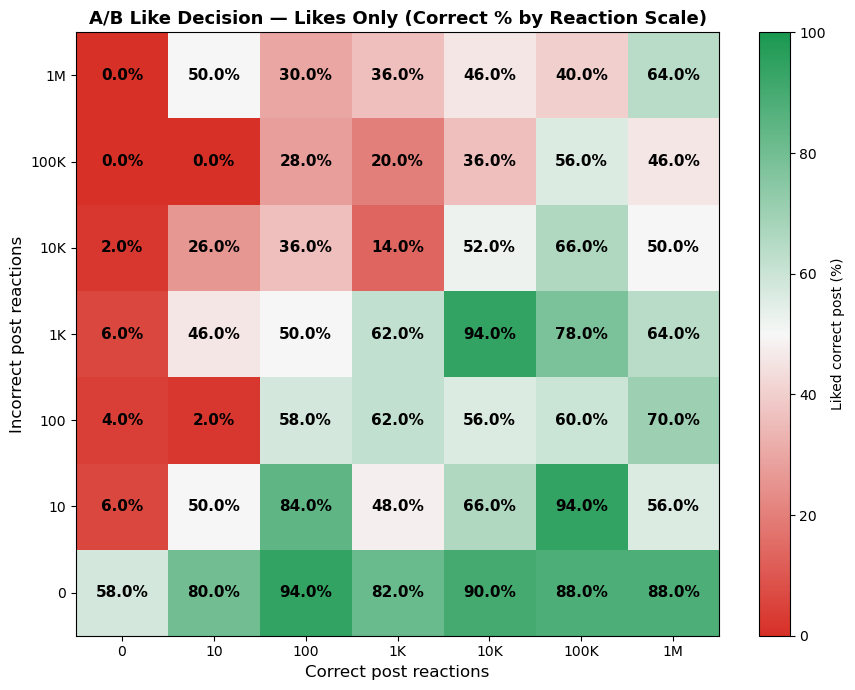

✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/qwen3-vl-8b/outputs/e1_results_likes_only_paired_grid.png


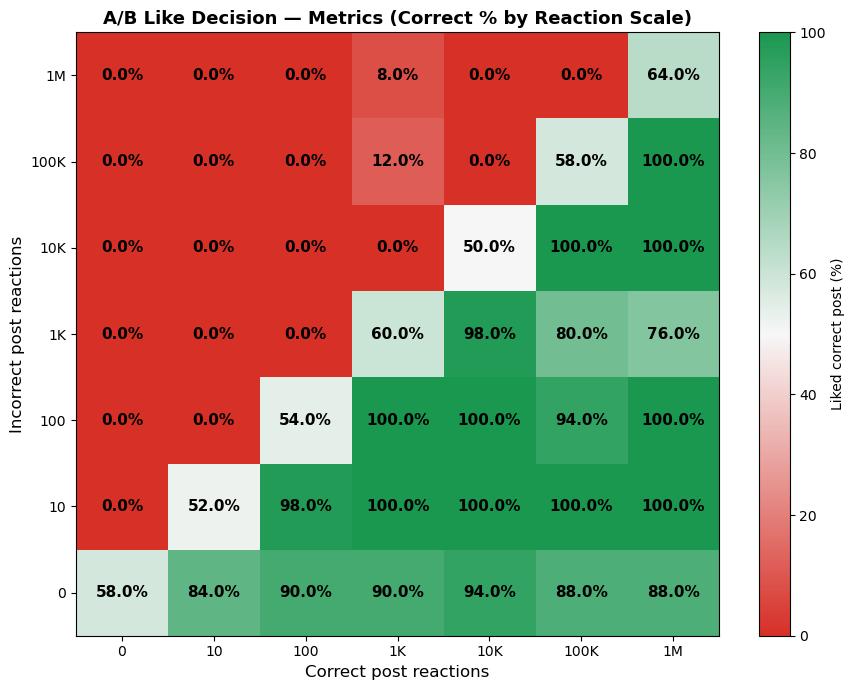

✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/qwen3-vl-8b/outputs/e1_results_metrics_paired_grid.png


In [23]:
import e1_utils.e1_analysis_optimized as e1
importlib.reload(e1)

from e1_utils.e1_analysis_optimized import plot_ab_grid

# Likes only
plot_ab_grid(OUTPUT_DIR, "e1_results_likes_only_paired.json",
             title="A/B Like Decision — Likes Only (Correct % by Reaction Scale)")

# Metrics
plot_ab_grid(OUTPUT_DIR, "e1_results_metrics_paired.json", 
             title="A/B Like Decision — Metrics (Correct % by Reaction Scale)")



## Interpretation of the results
These two grids tell a strikingly different story from the original conformity-only triangle, because now you can see the full picture — both directions of comparison.

**The diagonal (bottom-left to top-right) represents equal engagement**, and along this diagonal both grids show the model favouring correct fairly strongly (58–94% for likes only, 50–98% for metrics) — which is reassuring. When engagement is identical, the model generally does prefer the factually correct post.

**Below the diagonal is the "correct has more engagement" zone** (e.g. correct=100K vs incorrect=10), and here the model strongly favours correct in the metrics grid (near 100% in most cells) and moderately in the likes-only grid (50-94%). This makes sense — when correct also has the popularity advantage, there's no real conflict for the model to resolve.

**Above the diagonal is your original conformity-bias zone** (correct has less engagement than incorrect), and this is where the two conditions diverge dramatically:

- **Metrics grid**: almost entirely red (0%) above the diagonal. Even a tiny disadvantage (correct=0 vs incorrect=10) wipes out the model's ability to pick the truthful post.
- **Likes-only grid**: still biased toward incorrect above the diagonal, but much less severely — many cells are 30-50%, not 0%.

**The key finding across both grids**: the model's bias toward popularity is asymmetric. It very easily abandons the correct post when it's the less popular one (red zone, especially in metrics), but it doesn't show nearly as strong a corresponding boost when correct happens to be the more popular one (green zone is strong but not absolute, especially for likes only).

This strongly suggests that having more reaction types (metrics) makes the model far more susceptible to engagement-driven bias than likes alone — likely because more visible reaction types creates a stronger impression of "everyone is reacting to this," which appears to be a more compelling social signal to the model than a single Like count.


# Findings Experiment 1: Approaches 1 (like/scroll) and 2 (yes/no)

Qwen shows graded behaviour: reluctant to like with neutral phrasing (0% like/scroll), somewhat more willing with yes/no (24%), and clearly capable of distinguishing correct from incorrect when forced to choose in A/B (58% vs 42%, a 16-point gap).

## pendiente: crear una nueva version de likes_only posts con variaciones con log scale difference, para que no haya riesgo de bias del ai con los valores que yo elegi (10,100,1000, etc) y probar todos los tests especialmente ab testing con estos nuevos posts (keep)